In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
df = pd.read_csv("/content/spam_mail_classifier.csv")

print(df.head())
print(df.shape)
print(df.columns)

                                       email_text label
0              Let's catch up sometime next week!   ham
1  Don't forget to submit your project by Friday.   ham
2            Win a free iPhone now!!! Click here.  spam
3     Can you send me the report when it's ready?   ham
4    Meeting has been rescheduled to next Monday.   ham
(1000, 2)
Index(['email_text', 'label'], dtype='object')


In [3]:
print(df["label"].value_counts())

label
ham     583
spam    417
Name: count, dtype: int64


In [4]:
X = df["email_text"]
y = df["label"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 800
Testing samples: 200


In [6]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (800, 39)
Testing TF-IDF shape: (200, 39)


In [7]:
model = SVC(
    kernel="linear",
    random_state=42
)

model.fit(X_train_tfidf, y_train)

SVC(kernel='linear', random_state=42)

In [8]:
y_pred = model.predict(X_test_tfidf)

print(y_pred)

['spam' 'ham' 'ham' 'spam' 'spam' 'ham' 'spam' 'ham' 'ham' 'ham' 'spam'
 'ham' 'ham' 'spam' 'spam' 'spam' 'spam' 'ham' 'ham' 'spam' 'spam' 'ham'
 'spam' 'ham' 'spam' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham'
 'spam' 'ham' 'ham' 'ham' 'spam' 'spam' 'spam' 'ham' 'spam' 'spam' 'ham'
 'spam' 'ham' 'spam' 'ham' 'spam' 'spam' 'spam' 'spam' 'spam' 'ham' 'spam'
 'ham' 'ham' 'ham' 'ham' 'ham' 'spam' 'ham' 'ham' 'spam' 'spam' 'spam'
 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'spam' 'spam'
 'spam' 'spam' 'ham' 'ham' 'ham' 'spam' 'spam' 'ham' 'ham' 'ham' 'spam'
 'spam' 'ham' 'spam' 'ham' 'spam' 'spam' 'ham' 'ham' 'spam' 'ham' 'ham'
 'spam' 'spam' 'spam' 'spam' 'spam' 'spam' 'spam' 'ham' 'ham' 'spam' 'ham'
 'ham' 'ham' 'ham' 'ham' 'spam' 'spam' 'spam' 'spam' 'ham' 'ham' 'ham'
 'spam' 'ham' 'ham' 'ham' 'ham' 'spam' 'spam' 'ham' 'ham' 'spam' 'spam'
 'ham' 'ham' 'spam' 'ham' 'ham' 'spam' 'ham' 'ham' 'ham' 'ham' 'spam'
 'ham' 'ham' 'ham' 'spam' 'ham' 'ham' 'ham' 'ham' 'ham' 'spam' 'sp

In [9]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 1.0
Accuracy (%): 100.0


In [10]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[117   0]
 [  0  83]]


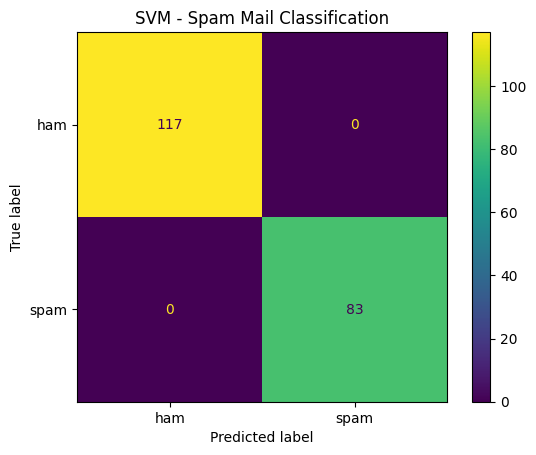

In [11]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()
plt.title("SVM - Spam Mail Classification")
plt.show()

In [12]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ham       1.00      1.00      1.00       117
        spam       1.00      1.00      1.00        83

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [13]:
new_email = [
    "Congratulations! You have won a free iPhone. Click here to claim your prize."
]

new_email_tfidf = vectorizer.transform(new_email)

prediction = model.predict(new_email_tfidf)

print("Email:", new_email[0])
print("Predicted Label:", prediction[0])

Email: Congratulations! You have won a free iPhone. Click here to claim your prize.
Predicted Label: spam


In [14]:
new_email = [
    "Please send me the project report before tomorrow's meeting."
]

new_email_tfidf = vectorizer.transform(new_email)

prediction = model.predict(new_email_tfidf)

print("Predicted Label:", prediction[0])

Predicted Label: ham
